# Olympic Athlete Analysis: 120 Years of Olympic History

This project explores the "120 Years of Olympic History" dataset, containing 271,116 records of individual athlete participation across every Olympic Games from Athens 1896 to Rio 2016. Each row represents one athlete competing in one event, with details including their age, height, weight, nationality, sport, and medal outcome.

**Goal:** clean the dataset, investigate data quality issues (missing values, duplicates, and outliers), and explore key patterns in Olympic history — including how gender participation has evolved, which countries and sports have dominated, how physical attributes vary by sport, and whether factors like age influence medal-winning success.

## 1. Data Loading & Understanding

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Data lives in the repo: data/athlete_data.csv (path is relative to the notebook/ folder)
df = pd.read_csv("../data/athlete_data.csv")
df.head()


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [2]:
df.shape

(271116, 15)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [4]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [5]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

**Observations:** The dataset has 271,116 rows and 15 columns spanning 1896–2016. `Age`, `Height`, and `Weight` have missing values (~3.5%, ~22%, ~23% respectively), and `Medal` is missing for ~85% of rows — but this is expected, since most athletes don't win a medal, rather than being a data quality issue.

## 2. Data Cleaning

### 2.1 Remove exact duplicate rows

In [6]:

# 1. Remove exact duplicates
df = df.drop_duplicates().copy()



In [7]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [8]:
df.describe()

,ID,Age,Height,Weight,Year
count,269731.000000,260416.000000,210917.000000,208204.000000,269731.000000
mean,68264.949591,25.454776,175.338953,70.701778,1978.623073
std,39026.253843,6.163869,10.518507,14.349027,29.752055
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34655.500000,21.000000,168.000000,60.000000,1960.000000
50%,68233.000000,24.000000,175.000000,70.000000,1988.000000
75%,102111.000000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


Removing exact duplicate rows reduced the dataset from 271,116 to 269,731 rows (1,385 duplicates removed).

### 2.2 Check for repeated athlete IDs

In [9]:
df['ID'].duplicated().sum()

np.int64(134160)

In [10]:
# See which athletes (IDs) appear most often - i.e. competed in the most events
print(df.groupby('ID').size().sort_values(ascending=False).head())


ID
106296    39
115354    38
119591    36
129196    32
89187     32
dtype: int64


**Note:** a repeated `ID` is expected and not an error — each row is one athlete-**event**, so an athlete competing in multiple events (e.g. a swimmer in 5 races) will naturally appear multiple times. This is different from the exact duplicate rows removed above.

### 2.3 Handle the Medal column

In [11]:
df['Medal'] = df['Medal'].fillna('No Medal')


In [12]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No Medal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,No Medal
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",No Medal
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",No Medal
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,No Medal


`Medal` being blank doesn't mean missing data — it means the athlete didn't win a medal. We make this explicit by filling it with `'No Medal'` instead of leaving it as `NaN`.

### 2.4 Impute missing Age, Height, and Weight

In [13]:
for col in ['Age', 'Height', 'Weight']:
    df[col] = df.groupby(['Sport', 'Sex'])[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())
    

In [14]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal
2,3,Gunnar Nielsen Aaby,M,24.0,178.0,73.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal
3,4,Edgar Lindenau Aabye,M,34.0,182.0,95.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No Medal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,No Medal
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",No Medal
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",No Medal
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,No Medal


In [15]:
print(df[['Age','Height','Weight']].isnull().sum())


Age       0
Height    0
Weight    0
dtype: int64


In [16]:
print(df['Medal'].unique())

['No Medal' 'Gold' 'Bronze' 'Silver']


In [17]:
df.isnull().sum()

ID        0
Name      0
Sex       0
Age       0
Height    0
Weight    0
Team      0
NOC       0
Games     0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
dtype: int64

We fill missing values using the **median within each Sport+Sex group** (since body type varies hugely by sport), with an overall median as a fallback for any group with no data at all. This preserves realistic values better than a single blanket average would.

### 2.5 Outlier Detection & Investigation

We use the IQR (Interquartile Range) method to flag statistical outliers in Age, Height, and Weight.

In [18]:
def find_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] < lower) | (data[col] > upper)]

for col in ['Age', 'Height', 'Weight']:
    outliers = find_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers found")

Age: 11442 outliers found
Height: 3024 outliers found
Weight: 5357 outliers found


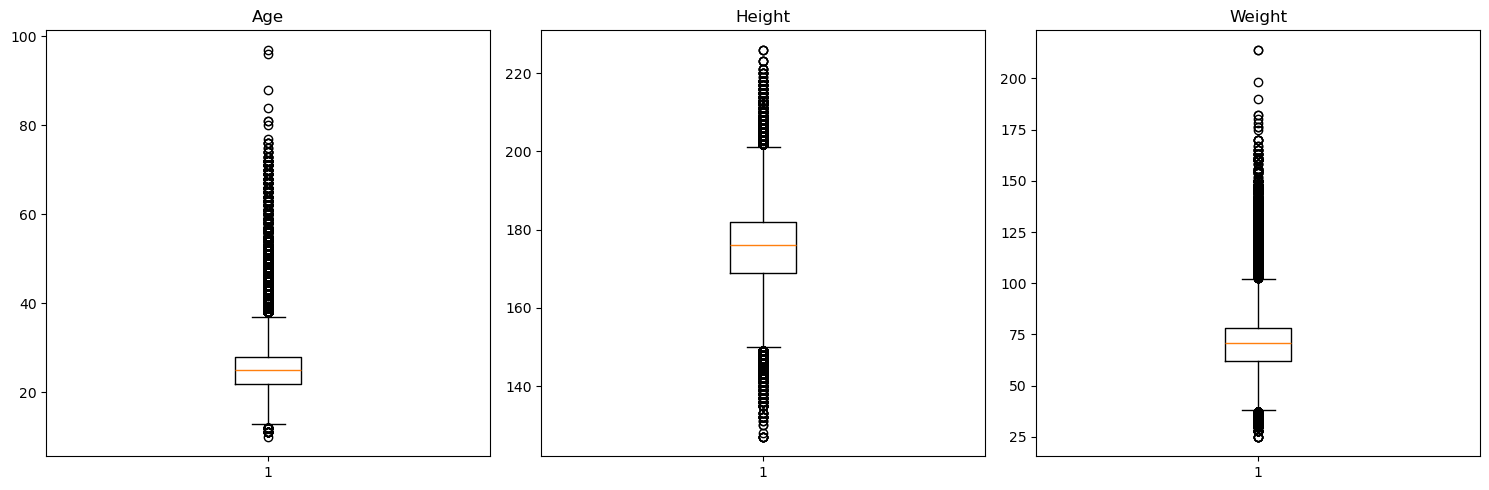

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, col in zip(axes, ['Age','Height','Weight']):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [20]:
# Investigate the most extreme values instead of assuming they're errors
print('--- Oldest athletes ---')
print(df.nlargest(5, 'Age')[['Name','Age','Sex','Sport','Year']])
print()
print('--- Tallest athletes ---')
print(df.nlargest(5, 'Height')[['Name','Height','Sex','Sport','Year']])
print()
print('--- Heaviest athletes ---')
print(df.nlargest(5, 'Weight')[['Name','Weight','Sex','Sport','Year']])


--- Oldest athletes ---
                              Name   Age Sex             Sport  Year
257054      John Quincy Adams Ward  97.0   M  Art Competitions  1928
98118                Winslow Homer  96.0   M  Art Competitions  1932
60861   Thomas Cowperthwait Eakins  88.0   M  Art Competitions  1932
9371         George Denholm Armour  84.0   M  Art Competitions  1948
154855        Robert Tait McKenzie  81.0   M  Art Competitions  1948

--- Tallest athletes ---
                         Name  Height Sex       Sport  Year
265040               Yao Ming   226.0   M  Basketball  2000
265041               Yao Ming   226.0   M  Basketball  2004
265042               Yao Ming   226.0   M  Basketball  2008
32376    Tommy Loren Burleson   223.0   M  Basketball  1972
207373  Arvydas Romas Sabonis   223.0   M  Basketball  1988

--- Heaviest athletes ---
                                 Name  Weight Sex      Sport  Year
23155               Ricardo Blas, Jr.   214.0   M       Judo  2008
23156          

**Conclusion on outliers:** manual investigation confirms these are genuine athletes, not data errors — e.g. very old 'athletes' competed in the historical Art Competitions (1912–1948), the tallest athlete is Yao Ming (basketball), and the heaviest are super-heavyweight judo/wrestling competitors. These values were **kept, not removed**, since deleting them would erase real athletic diversity rather than correct an error.

## 3. Feature Engineering
Feature engineering is performed to create meaningful variables from the existing dataset that can support further analysis and visualization.

In [21]:
df['Medalist'] = df['Medal'] != 'No Medal'

In [22]:
df['Medalist'].value_counts()

Medalist
False    229959
True      39772
Name: count, dtype: int64

In [23]:
df[['Medal', 'Medalist']].head(10)

,Medal,Medalist
0,No Medal,False
1,No Medal,False
2,No Medal,False
3,Gold,True
4,No Medal,False
5,No Medal,False
6,No Medal,False
7,No Medal,False
8,No Medal,False
9,No Medal,False


## 4. Exploratory Data Analysis (EDA)

### 4.1 Gender Participation Over Time

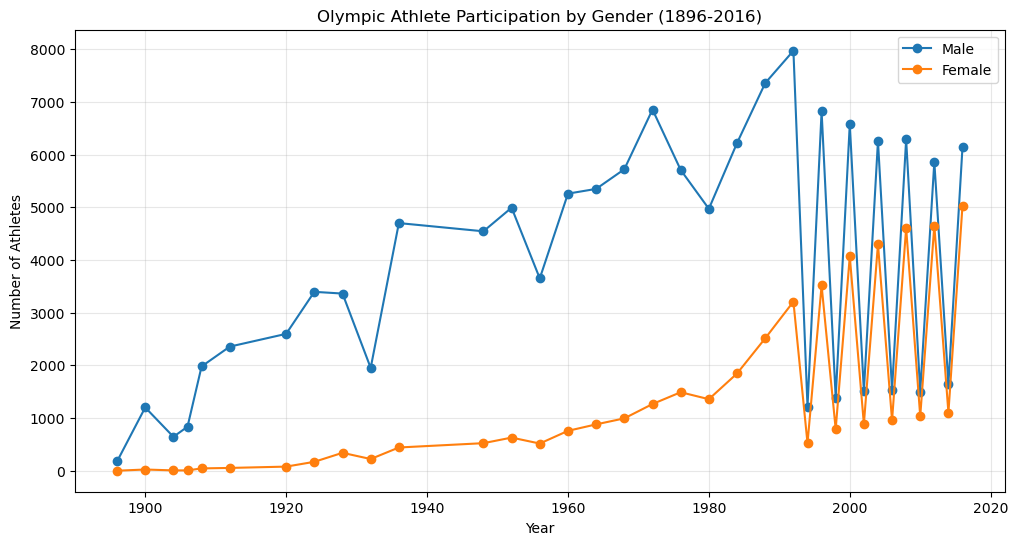

In [24]:
gender_trend = df.drop_duplicates(subset=['ID','Year']).groupby(['Year','Sex']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
plt.plot(gender_trend.index, gender_trend['M'], label='Male', marker='o')
plt.plot(gender_trend.index, gender_trend['F'], label='Female', marker='o')
plt.title('Olympic Athlete Participation by Gender (1896-2016)')
plt.xlabel('Year')
plt.ylabel('Number of Athletes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Insight:** Female participation increased substantially across the Olympic Games, while male participation remained higher overall. The gap between male and female participation became considerably smaller by 2016.

### What is the distribution of male and female participation?

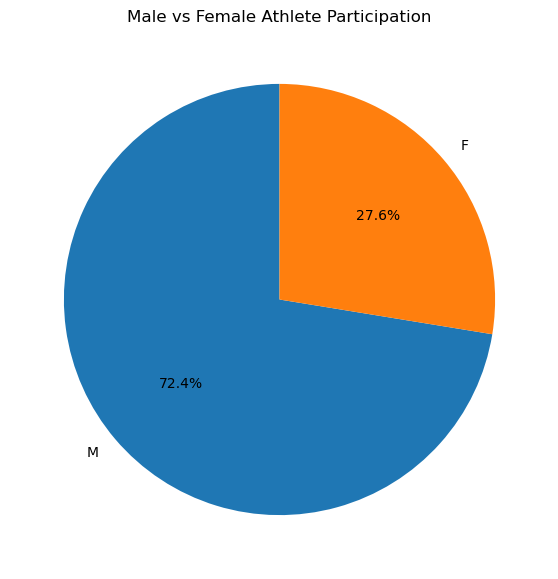

In [25]:
# 2. Male vs Female Participation

gender_count = df['Sex'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Male vs Female Athlete Participation')

plt.show()

### 4.2 Trend of Unique Athlete Participation Across Olympic Games

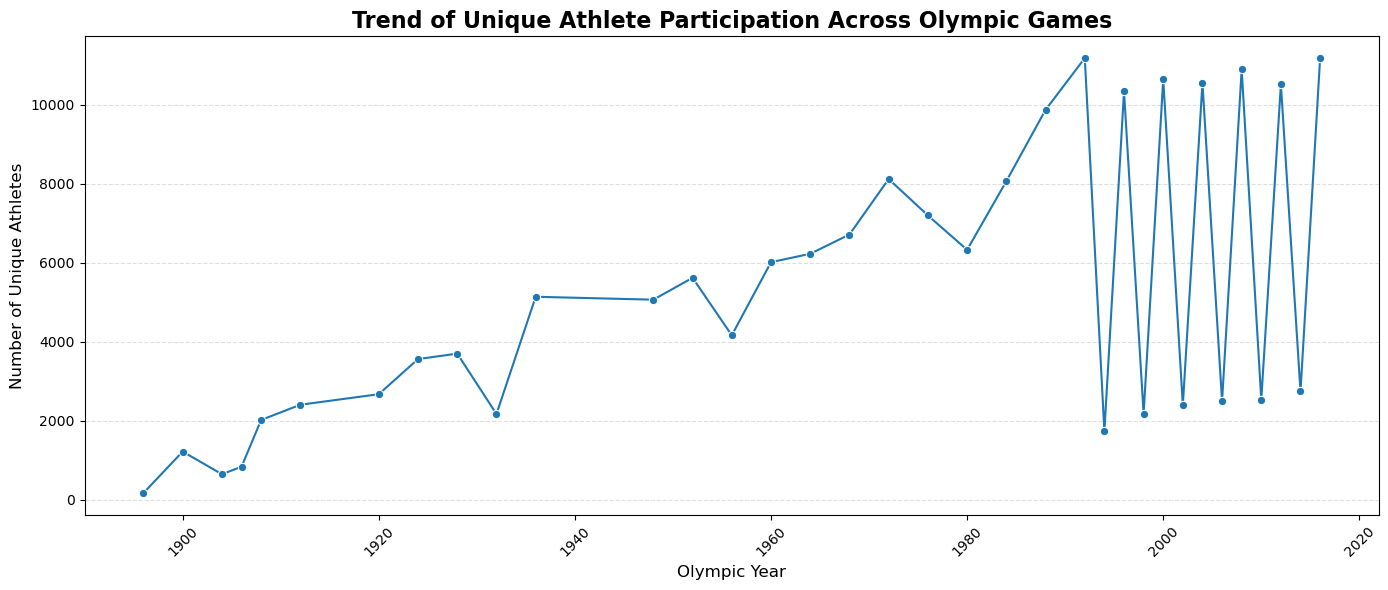

In [26]:
yearly_participation = df.groupby('Year')['ID'].nunique()

plt.figure(figsize=(14,6))

sns.lineplot(
    x=yearly_participation.index,
    y=yearly_participation.values,
    marker='o'
)

plt.title('Trend of Unique Athlete Participation Across Olympic Games',
          fontsize=16, fontweight='bold')

plt.xlabel('Olympic Year', fontsize=12)
plt.ylabel('Number of Unique Athletes', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Insight:** The analysis shows an overall increase in unique athlete participation across the Olympic Games, indicating the expansion of Olympic participation over time. The fluctuations in later years are partly influenced by the separate scheduling of Summer and Winter Games.

### 4.3 Top Countries by Medal Count

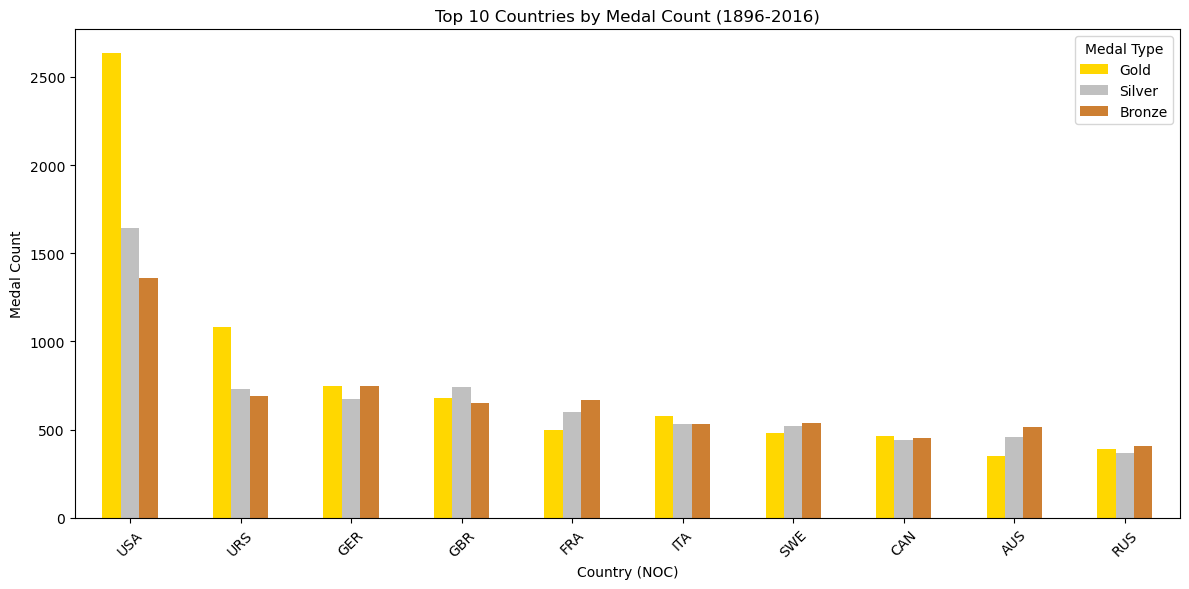

In [27]:
medals_only = df[df['Medal'] != 'No Medal']
top10_nocs = medals_only.groupby('NOC').size().sort_values(ascending=False).head(10).index.tolist()

breakdown = medals_only[medals_only['NOC'].isin(top10_nocs)].groupby(['NOC','Medal']).size().unstack(fill_value=0)
breakdown = breakdown.reindex(top10_nocs)[['Gold','Silver','Bronze']]

breakdown.plot(kind='bar', figsize=(12,6), color=['gold','silver','#cd7f32'])# bronze is not in the 150 colors so we used this #cd7 that stuff
plt.title('Top 10 Countries by Medal Count (1896-2016)')
plt.xlabel('Country (NOC)')
plt.ylabel('Medal Count')
plt.xticks(rotation=45)
plt.legend(title='Medal Type')
plt.tight_layout()
plt.show()

**Insight:** The medal distribution shows substantial differences in total medal counts across the leading NOCs. The United States has the highest recorded medal count in this dataset, followed by other historically strong Olympic participants.

### 4.4 Age Distribution of Athletes

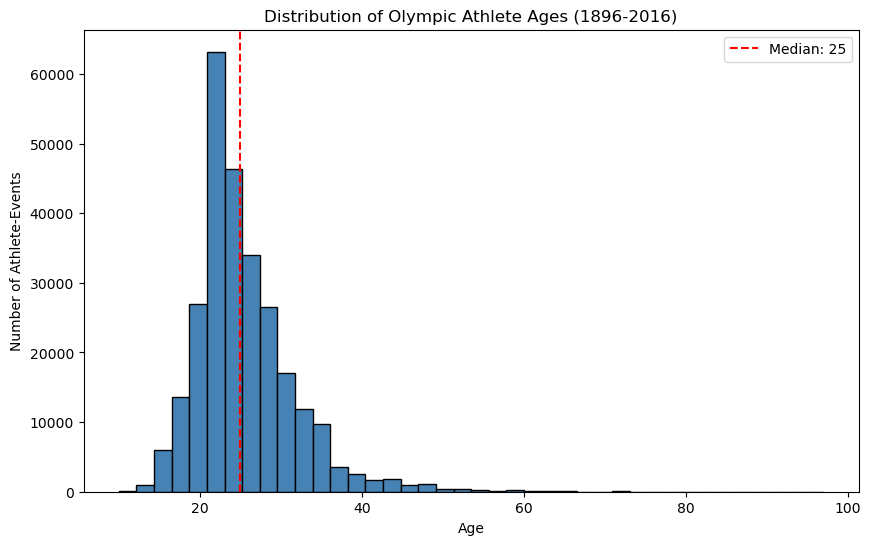

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['Age'], bins=40, color='steelblue', edgecolor='black')
plt.axvline(df['Age'].median(), color='red', linestyle='--', label=f'Median: {df["Age"].median():.0f}')
plt.title('Distribution of Olympic Athlete Ages (1896-2016)')
plt.xlabel('Age')
plt.ylabel('Number of Athlete-Events')
plt.legend()
plt.show()

**Insight:** Most athlete records fall within the young-adult age range, with participation concentrated around the early twenties. The distribution also contains a smaller number of older and younger participants.

### 4.5 Height by Sport

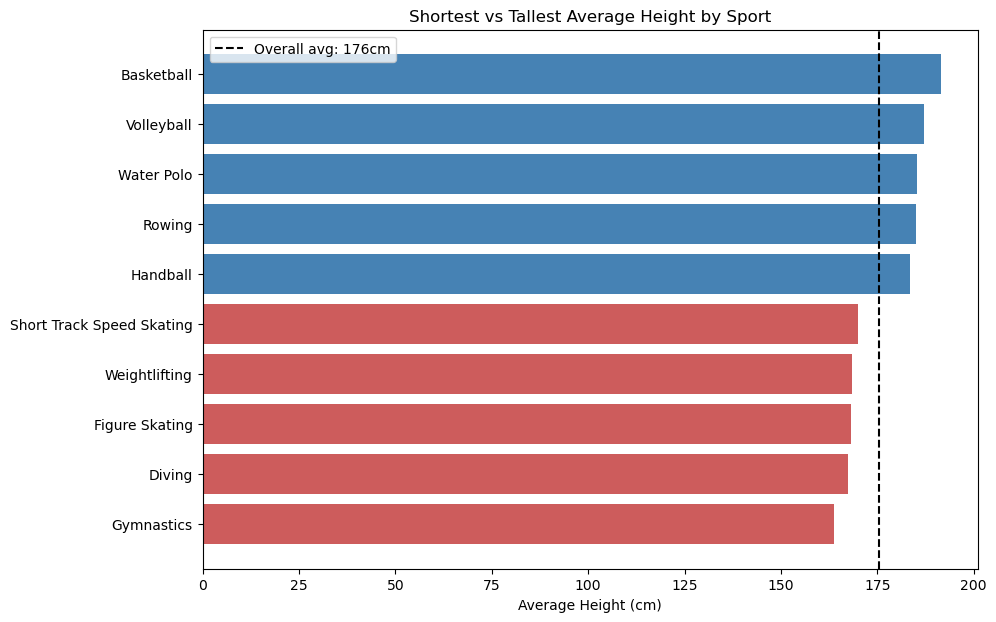

In [29]:
sport_counts = df['Sport'].value_counts()
big_sports = sport_counts[sport_counts > 1000].index  # only sports with enough data to trust the average

avg_height = df[df['Sport'].isin(big_sports)].groupby('Sport')['Height'].mean().sort_values()
top_bottom = pd.concat([avg_height.head(5), avg_height.tail(5)])

plt.figure(figsize=(10,7))
colors = ['indianred']*5 + ['steelblue']*5
plt.barh(top_bottom.index, top_bottom.values, color=colors)
plt.axvline(df['Height'].mean(), color='black', linestyle='--', label=f'Overall avg: {df["Height"].mean():.0f}cm')
plt.xlabel('Average Height (cm)')
plt.title('Shortest vs Tallest Average Height by Sport')
plt.legend()
plt.show()

**Insight:** Average athlete height varies considerably across sports. Basketball, Volleyball, Water Polo, Rowing, and Handball show relatively higher average heights among the sports included in the analysis.

### 4.6 Most Popular Sports Over Time

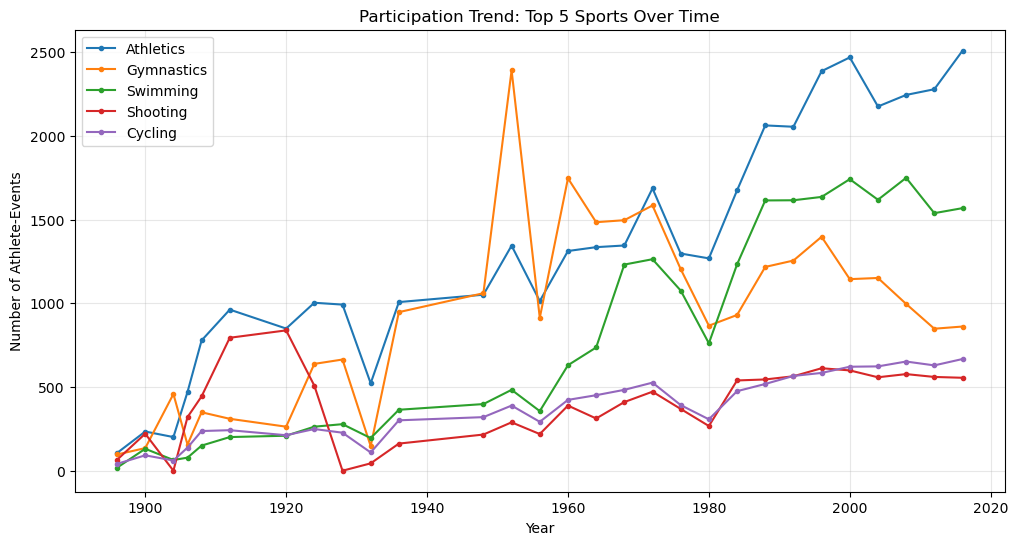

In [30]:
# most popular sports over time
top5_sports = df['Sport'].value_counts().head(5).index.tolist()

trend = df[df['Sport'].isin(top5_sports)].groupby(['Year','Sport']).size().unstack(fill_value=0)
trend = trend[top5_sports]

plt.figure(figsize=(12,6))
for sport in top5_sports:
    plt.plot(trend.index, trend[sport], marker='o', markersize=3, label=sport)
plt.title('Participation Trend: Top 5 Sports Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Athlete-Events')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Insight:** Athletics shows consistently high participation across the historical period, while the participation trends of other major sports vary over time.

### 4.7 Growth of Olympic Globalization

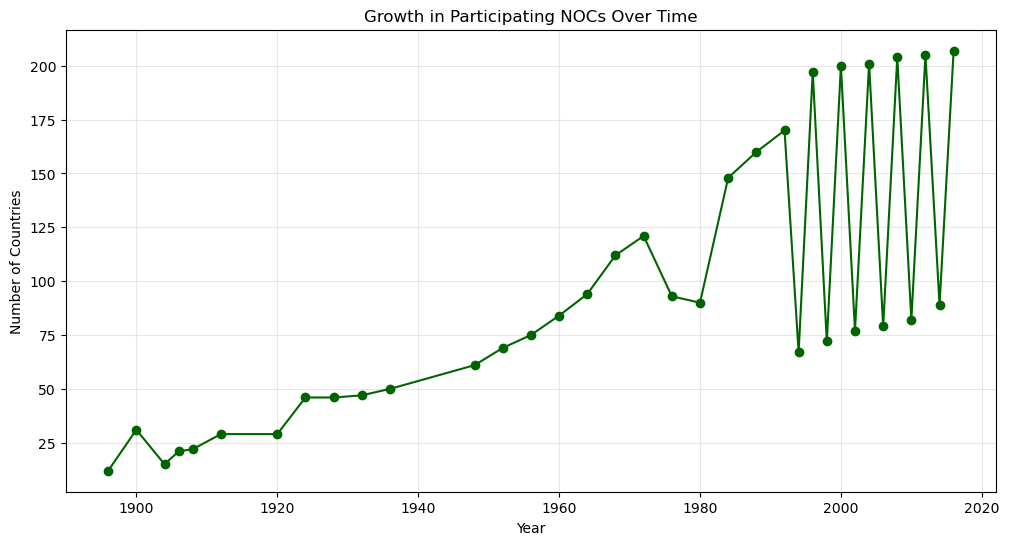

In [31]:
# number of countries over time
countries_per_year = df.groupby('Year')['NOC'].nunique().sort_index()

plt.figure(figsize=(12,6))
plt.plot(countries_per_year.index, countries_per_year.values, marker='o', color='darkgreen')
plt.title('Growth in Participating NOCs Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Countries')
plt.grid(alpha=0.3)
plt.show()

**Insight:** The number of participating NOCs increased substantially over the Olympic history, indicating the expansion of international participation in the Games.

### 4.8 Does Age Affect Medal-Winning Chances?

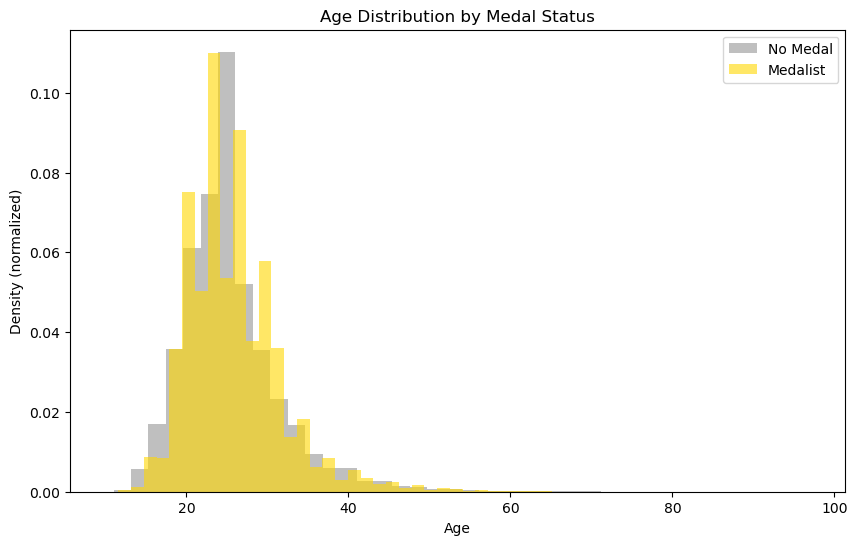

In [32]:
#Does Age Affect Medal-Winning Chances?

df['Medalist'] = df['Medal'] != 'No Medal'
medalist_age = df[df['Medalist']]['Age']
non_medalist_age = df[~df['Medalist']]['Age']

plt.figure(figsize=(10,6))
plt.hist(non_medalist_age, bins=40, alpha=0.5, label='No Medal', color='gray', density=True)
plt.hist(medalist_age, bins=40, alpha=0.6, label='Medalist', color='gold', density=True)
plt.title('Age Distribution by Medal Status')
plt.xlabel('Age')
plt.ylabel('Density (normalized)')
plt.legend()
plt.show()

**Insight:** The average age of medalists and non-medalists is relatively similar in this dataset. This suggests that age alone does not show a strong association with medal status.

### 4.9 Relationship Between Height and Weight

Correlation: 0.7971289749622616


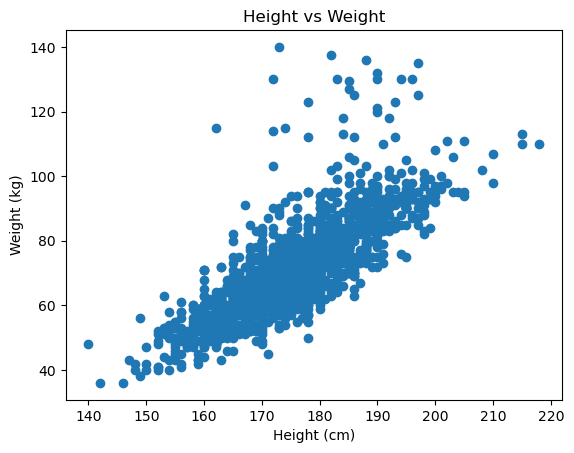

In [33]:
#Relationship Between Height and Weight (Correlation)
import matplotlib.pyplot as plt

# Step 1: Calculate correlation between Height and Weight
correlation = df['Height'].corr(df['Weight'])
print("Correlation:", correlation)

# Step 2: Take a small sample so the chart isn't too crowded
sample = df.sample(2000)

# Step 3: Plot Height vs Weight
plt.scatter(sample['Height'], sample['Weight'])
plt.title('Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

**Insight:** The scatter plot shows a positive relationship between height and weight, indicating that athlete records with greater height tend to be associated with greater weight. However, the relationship varies across individual observations.

## Key Insights

1. **Gender Participation:** Female participation increased substantially across the Olympic Games, while male participation remained higher overall. The participation gap became considerably smaller by 2016.

2. **Medal Distribution:** Medal counts vary considerably across the leading NOCs. The United States has the highest recorded medal count in this dataset, followed by other historically prominent Olympic participants.

3. **Age Profile:** Most athlete records are concentrated around the young-adult age range, with participation particularly common in the early twenties. The dataset also contains a smaller number of older participants.

4. **Physical Attributes by Sport:** Average athlete height varies considerably across sports. Basketball, Volleyball, Water Polo, Rowing, and Handball show relatively higher average heights, while several other sports have lower average values.

5. **Sport Participation Trends:** Athletics shows consistently high participation across the historical period, while participation trends in other major sports vary over time.

6. **Olympic Globalization:** The number of participating NOCs increased substantially over Olympic history, indicating the expansion of international participation in the Games.

7. **Age and Medal Status:** The average age of medalists and non-medalists is relatively similar in this dataset. This indicates that age alone does not show a strong association with medal status.

8. **Height-Weight Relationship:** The analysis shows a positive relationship between height and weight among athlete records, although the relationship varies across individual observations.


# Data Limitations

### 1. Athlete-Event Level Data
Each row represents an athlete participating in an event rather than one unique athlete. Therefore, athletes competing in multiple events can appear multiple times.

### 2. Missing Historical Data
Age, Height and Weight contained missing values, particularly in historical records. These values were imputed using the median within Sport and Sex groups, with an overall median as a fallback.

### 3. Medal Column Interpretation
A missing Medal value represents an athlete who did not win a medal rather than missing information. Therefore, these values were converted to "No Medal".

### 4. Team Events
Team events can produce multiple medal records for the same medal-winning event because each participating athlete has a separate record.

### 5. Outliers
Statistical outliers were identified in Age, Height and Weight. These were investigated rather than automatically removed because extreme values may represent genuine athletes.

### 6. Historical Differences
The dataset covers more than a century of Olympic history, so changes in participation, sports, countries and event structures across different periods can affect comparisons.

## Conclusion

This analysis provides a comprehensive view of 120 years of Olympic history, from 1896 to 2016. The analysis shows major changes in athlete participation, gender representation and the global reach of the Games.

It also highlights differences in physical characteristics across sports and shows a strong positive relationship between height and weight. The analysis of age and medal status shows that medalists and non-medalists have similar average ages, suggesting that age alone does not strongly explain medal-winning status.

Overall, this project demonstrates how data cleaning, feature engineering and exploratory data analysis can be used to identify meaningful patterns in a large historical dataset.